In [3]:
import cv2
import numpy as np
import os

# Global variables for drawing the line
drawing = False
line_start = None
line_end = None
scale = None

def draw_line(event, x, y, flags, param):
    global drawing, line_start, line_end
    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
        line_start = (x, y)
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False
        line_end = (x, y)
        cv2.line(param, line_start, line_end, (0, 255, 0), 2)
        cv2.imshow("Image", param)

def calculate_scale(image, real_distance):
    global line_start, line_end, scale
    print("Draw a line on the image and press any key when done.")
    cv2.imshow("Image", image)
    cv2.setMouseCallback("Image", draw_line, param=image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    if line_start and line_end:
        pixel_distance = np.sqrt((line_end[0] - line_start[0])**2 + (line_end[1] - line_start[1])**2)
        scale = real_distance / pixel_distance
        print(f"Scale calculated: {scale} units per pixel.")
    else:
        print("No line was drawn. Exiting.")
        exit()

def process_image(image_path, output_folder, real_distance):
    global scale
    image = cv2.imread(image_path)
    if image is None:
        print(f"Failed to load image: {image_path}")
        return []

    # Prompt the user to draw a line and calculate the scale
    if scale is None:
        calculate_scale(image.copy(), real_distance)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Detect edges using Canny edge detection
    edges = cv2.Canny(gray, 100, 200)

    # Label connected components in the edge image
    num_labels, labels = cv2.connectedComponents(edges)

    # Create a blank output image
    output_image = np.zeros_like(image)

    edge_data = []  # To store data for each edge

    for label in range(1, num_labels):  # Skip the background label (0)
        # Extract points belonging to the current edge
        edge_points = np.argwhere(labels == label)

        # Convert pixel coordinates to real-world coordinates
        real_world_points = [(x * scale, y * scale) for x, y in edge_points]

        # Calculate the length of the edge
        edge_length = len(edge_points) * scale

        # Calculate the average contrast of the edge
        contrast_values = [gray[x, y] for x, y in edge_points]
        avg_contrast = np.mean(contrast_values)

        # Fit a polynomial curve to the real-world points
        real_world_points = np.array(real_world_points)
        x_coords = real_world_points[:, 1]  # Real-world x-coordinates
        y_coords = real_world_points[:, 0]  # Real-world y-coordinates
        if len(x_coords) > 2:  # Ensure there are enough points to fit a curve
            polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
            edge_data.append({
                "length": edge_length,
                "avg_contrast": avg_contrast,
                "coefficients": polynomial_coefficients,
                "x_coords": x_coords,
                "y_coords": y_coords
            })
            print(f"Edge {label}: Length = {edge_length:.2f} units, Avg Contrast = {avg_contrast:.2f}")
            print(f"Polynomial coefficients: {polynomial_coefficients}")
        else:
            print(f"Edge {label}: Not enough points to fit a curve.")

        # Draw the edge on the output image
        for x, y in edge_points:
            output_image[x, y] = (255, 255, 255)  # Draw edges in white

    # Save the output image
    output_path = os.path.join(output_folder, f"processed_{os.path.basename(image_path)}")
    cv2.imwrite(output_path, output_image)
    print(f"Processed and saved: {output_path}")

    return edge_data

def process_folder(folder_path, output_folder, real_distance):
    os.makedirs(output_folder, exist_ok=True)
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            process_image(os.path.join(folder_path, filename), output_folder, real_distance)

In [2]:
# Example usage
folder_path = 'test-cans/8.16x4.83/'  # Replace with your folder path
single_image_path = 'test-cans/8.16x4.83/pepsi.png'  # Replace with your single image path
output_folder = 'output-images/'  # Replace with your output folder path
real_distance = 8.16  # Replace with the real-world distance for the drawn line

# Process a folder of images
#process_folder(folder_path, output_folder, real_distance)

# Process a single image
process_image(single_image_path, output_folder, real_distance)

Draw a line on the image and press any key when done.
Scale calculated: 0.011147530581379912 units per pixel.
Edge 1: Length = 25.19 units, Avg Contrast = 113.22
Polynomial coefficients: [9.60041703e-17 1.63629017e-15 2.21278482e+00]
Edge 2: Length = 8.16 units, Avg Contrast = 95.02
Polynomial coefficients: [  1.40476269 -20.09692772  72.30214767]
Edge 3: Length = 6.53 units, Avg Contrast = 123.17
Polynomial coefficients: [ 0.02826905 -0.31541817  1.86385712]
Edge 4: Length = 0.08 units, Avg Contrast = 123.86
Polynomial coefficients: [  -34.95037638   554.88311684 -2202.24924565]
Edge 5: Length = 0.29 units, Avg Contrast = 123.04
Polynomial coefficients: [  10.62889893 -169.21677354  673.64206519]
Edge 6: Length = 0.22 units, Avg Contrast = 103.40
Polynomial coefficients: [  48.98251428 -655.29875381 2191.82987201]
Edge 7: Length = 0.52 units, Avg Contrast = 117.28
Polynomial coefficients: [ -11.23193657  153.18947999 -522.09551181]
Edge 8: Length = 0.38 units, Avg Contrast = 109.65
Po

C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\1362703041.py:79: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\1362703041.py:79: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\1362703041.py:79: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\1362703041.py:79: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\1362703041.py:79: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 127: Length = 0.03 units, Avg Contrast = 198.00
Polynomial coefficients: [0.00750468 0.04542664 0.27497242]
Edge 128: Length = 1.98 units, Avg Contrast = 68.70
Polynomial coefficients: [-1.44433973  2.65670827  0.0476583 ]
Edge 129: Not enough points to fit a curve.
Edge 130: Length = 0.04 units, Avg Contrast = 121.50
Polynomial coefficients: [ 8.90669544e-13 -1.92827158e-12  8.24917263e-01]
Edge 131: Length = 0.09 units, Avg Contrast = 149.12
Polynomial coefficients: [-41.95924219 109.56451613 -70.6735459 ]
Edge 132: Length = 0.98 units, Avg Contrast = 113.59
Polynomial coefficients: [  2.10793633 -33.45482754 133.69097634]
Edge 133: Not enough points to fit a curve.
Edge 134: Not enough points to fit a curve.
Edge 135: Length = 0.82 units, Avg Contrast = 222.89
Polynomial coefficients: [ 0.13858133 -1.15519841  3.30118382]
Edge 136: Length = 0.03 units, Avg Contrast = 190.33
Polynomial coefficients: [0.01658564 0.06933333 0.2898358 ]
Edge 137: Length = 0.03 units, Avg Contrast =

C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\1362703041.py:79: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\1362703041.py:79: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\1362703041.py:79: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\1362703041.py:79: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\1362703041.py:79: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 335: Not enough points to fit a curve.
Edge 336: Not enough points to fit a curve.
Edge 337: Not enough points to fit a curve.
Edge 338: Length = 0.23 units, Avg Contrast = 120.19
Polynomial coefficients: [  1.32067085 -21.57246793  89.96036581]
Edge 339: Length = 0.04 units, Avg Contrast = 96.00
Polynomial coefficients: [  -22.4264915    309.24999976 -1064.20457988]
Edge 340: Not enough points to fit a curve.
Edge 341: Not enough points to fit a curve.
Edge 342: Length = 0.51 units, Avg Contrast = 125.65
Polynomial coefficients: [  13.97758272 -225.72012321  913.28462801]
Edge 343: Length = 0.67 units, Avg Contrast = 125.13
Polynomial coefficients: [ -15.24710018  243.10622645 -966.75858254]
Edge 344: Not enough points to fit a curve.
Edge 345: Not enough points to fit a curve.
Edge 346: Length = 0.04 units, Avg Contrast = 47.75
Polynomial coefficients: [ 1.43343919e-12 -1.91138758e-11  1.96196538e+00]
Edge 347: Not enough points to fit a curve.
Edge 348: Not enough points to fit

C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\1362703041.py:79: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\1362703041.py:79: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\1362703041.py:79: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\1362703041.py:79: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\1362703041.py:79: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 527: Length = 0.19 units, Avg Contrast = 155.94
Polynomial coefficients: [  -2.63297436   39.79814771 -147.23890428]
Edge 528: Length = 0.91 units, Avg Contrast = 113.67
Polynomial coefficients: [-0.13319849  2.04932927 -4.70349846]
Edge 529: Length = 0.08 units, Avg Contrast = 122.14
Polynomial coefficients: [  25.63027602 -396.96428571 1540.18701709]
Edge 530: Length = 0.12 units, Avg Contrast = 184.82
Polynomial coefficients: [  42.62048161 -119.44343891   86.82256715]
Edge 531: Length = 1.95 units, Avg Contrast = 123.15
Polynomial coefficients: [ 0.01561039 -0.15710884  3.54122347]
Edge 532: Length = 0.12 units, Avg Contrast = 131.27
Polynomial coefficients: [ -10.40404247  139.18814448 -462.34383135]
Edge 533: Length = 0.10 units, Avg Contrast = 147.56
Polynomial coefficients: [  22.42649151 -301.2499999  1014.82659368]
Edge 534: Length = 0.09 units, Avg Contrast = 137.25
Polynomial coefficients: [-1.71002361e-08  2.31419303e-07  3.16589790e+00]
Edge 535: Length = 0.10 units,

C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\1362703041.py:79: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\1362703041.py:79: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\1362703041.py:79: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\1362703041.py:79: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve


Edge 1: Length = 25.15 units, Avg Contrast = 113.22
Polynomial coefficients: [1.87380962e-16 9.95188393e-16 2.20894597e+00]
Edge 2: Length = 8.15 units, Avg Contrast = 95.02
Polynomial coefficients: [  1.40720398 -20.09692772  72.17671438]
Edge 3: Length = 6.52 units, Avg Contrast = 123.17
Polynomial coefficients: [ 0.02831817 -0.31541817  1.86062361]
Edge 4: Length = 0.08 units, Avg Contrast = 123.86
Polynomial coefficients: [  -35.01111537   554.88311674 -2198.42867567]
Edge 5: Length = 0.29 units, Avg Contrast = 123.04
Polynomial coefficients: [  10.64737051 -169.21677354  672.47339805]
Edge 6: Length = 0.22 units, Avg Contrast = 103.40
Polynomial coefficients: [  49.06763921 -655.29875381 2188.02737849]
Edge 7: Length = 0.52 units, Avg Contrast = 117.28
Polynomial coefficients: [ -11.25145615  153.18947999 -521.18975502]
Edge 8: Length = 0.38 units, Avg Contrast = 109.65
Polynomial coefficients: [  17.86414972 -245.55151643  844.00580086]
Edge 9: Length = 0.08 units, Avg Contrast =

C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\3817140784.py:81: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\3817140784.py:81: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\3817140784.py:81: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\3817140784.py:81: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\3817140784.py:81: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 175: Not enough points to fit a curve.
Edge 176: Length = 0.06 units, Avg Contrast = 188.60
Polynomial coefficients: [ 1.22721569e-12 -1.00000000e+00  5.70876214e+00]
Edge 177: Length = 0.03 units, Avg Contrast = 201.00
Polynomial coefficients: [0.01082534 0.06143791 0.34868333]
Edge 178: Length = 0.03 units, Avg Contrast = 190.67
Polynomial coefficients: [0.00993484 0.05947955 0.35610212]
Edge 179: Length = 0.11 units, Avg Contrast = 77.60
Polynomial coefficients: [  15.03425047 -200.76959846  671.32142805]
Edge 180: Length = 0.49 units, Avg Contrast = 89.02
Polynomial coefficients: [  -2.59720378   34.79294752 -115.41805152]
Edge 181: Not enough points to fit a curve.
Edge 182: Length = 0.26 units, Avg Contrast = 102.00
Polynomial coefficients: [  -2.27481962   32.09417002 -112.11968475]
Edge 183: Length = 0.20 units, Avg Contrast = 118.72
Polynomial coefficients: [ 1.18730063e-07 -1.82068382e-06  1.09613382e+00]
Edge 184: Length = 0.13 units, Avg Contrast = 121.08
Polynomial co

C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\3817140784.py:81: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\3817140784.py:81: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\3817140784.py:81: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\3817140784.py:81: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\3817140784.py:81: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 352: Not enough points to fit a curve.
Edge 353: Not enough points to fit a curve.
Edge 354: Length = 0.07 units, Avg Contrast = 50.33
Polynomial coefficients: [ 2.03408425e-13 -2.84905174e-12  1.95856167e+00]
Edge 355: Length = 0.03 units, Avg Contrast = 51.33
Polynomial coefficients: [-3.64862507e-13  5.15182796e-12  1.95856167e+00]
Edge 356: Length = 0.07 units, Avg Contrast = 49.50
Polynomial coefficients: [-2.63421572e-13  3.77797091e-12  1.95856167e+00]
Edge 357: Length = 0.03 units, Avg Contrast = 49.00
Polynomial coefficients: [-4.03017866e-14  5.83966085e-13  1.95856167e+00]
Edge 358: Length = 0.03 units, Avg Contrast = 48.00
Polynomial coefficients: [-5.83852466e-13  8.59532303e-12  1.95856167e+00]
Edge 359: Not enough points to fit a curve.
Edge 360: Length = 0.06 units, Avg Contrast = 51.00
Polynomial coefficients: [-9.51822167e-13  1.41658214e-11  1.95856167e+00]
Edge 361: Not enough points to fit a curve.
Edge 362: Not enough points to fit a curve.
Edge 363: Not enou

C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\3817140784.py:81: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\3817140784.py:81: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\3817140784.py:81: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\3817140784.py:81: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\3817140784.py:81: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

Edge 483: Length = 0.03 units, Avg Contrast = 183.33
Polynomial coefficients: [-1.97019172e-12  4.40627886e-12  2.74866325e+00]
Edge 484: Length = 0.14 units, Avg Contrast = 215.38
Polynomial coefficients: [0.69281255 0.80952381 0.94589626]
Edge 485: Length = 0.97 units, Avg Contrast = 130.97
Polynomial coefficients: [ 0.01201005 -0.04152217  2.82411179]
Edge 486: Length = 0.31 units, Avg Contrast = 89.89
Polynomial coefficients: [  10.16385682 -134.5494392   448.13405123]
Edge 487: Length = 2.33 units, Avg Contrast = 121.25
Polynomial coefficients: [ -0.37921383   5.33730095 -15.88436281]
Edge 488: Length = 1.58 units, Avg Contrast = 130.46
Polynomial coefficients: [ -0.9594085   14.07222614 -48.70699967]
Edge 489: Length = 0.26 units, Avg Contrast = 110.78
Polynomial coefficients: [  34.62117994 -497.31870111 1788.80437113]
Edge 490: Length = 0.34 units, Avg Contrast = 123.81
Polynomial coefficients: [ 0.34852479 -5.05806795 21.14805112]
Edge 491: Not enough points to fit a curve.
Ed

C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\3817140784.py:81: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\3817140784.py:81: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\3817140784.py:81: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\3817140784.py:81: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2)  # Fit a quadratic curve
C:\Users\Eoin\AppData\Local\Temp\ipykernel_28324\3817140784.py:81: RankWarning: Polyfit may be poorly conditioned
  polynomial_coefficients = np.polyfit(x_coords, y_coords, deg=2) 

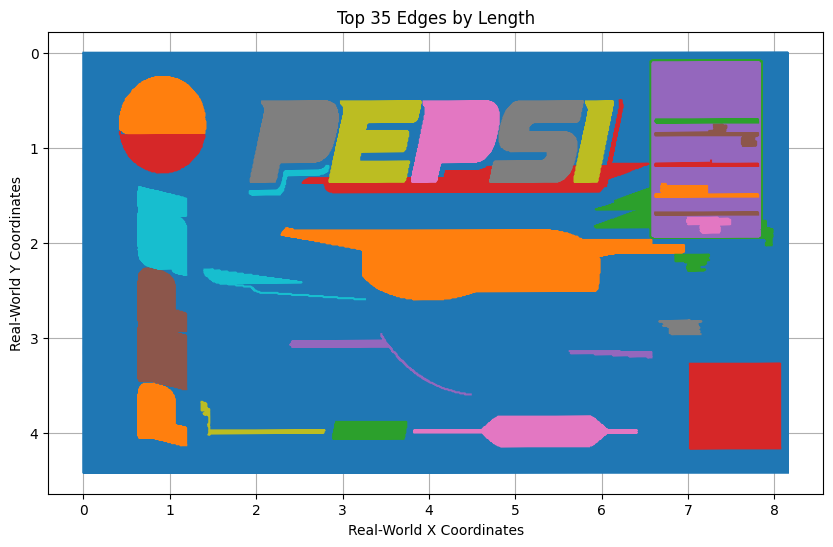

In [ ]:
import matplotlib.pyplot as plt

# Process the image and get edge data
edge_data = process_image(single_image_path, output_folder, real_distance)

# Sort edges by length in descending order
sorted_edges = sorted(edge_data, key=lambda e: e["length"], reverse=True)

# Number of edges to plot
x = 200  # Replace with the desired number of edges to plot

# Plot the first x edges
plt.figure(figsize=(10, 6))
for i, edge in enumerate(sorted_edges[:x]):
    plt.plot(edge["x_coords"], edge["y_coords"], label=f"Edge {i+1} (Length: {edge['length']:.2f} inches)")

plt.title(f"Top {x} Edges by Length")
plt.xlabel("Real-World X Coordinates (inches)")
plt.ylabel("Real-World Y Coordinates (inches)")
plt.gca().invert_yaxis()  # Invert the y-axis to match the image coordinate system
#plt.legend()
plt.grid()
plt.show()